In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# TASK 1

In [2]:
df = pd.read_csv("student_depression.csv")
df

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
497,Male,26,5.0,2.0,More than 8 hours,Unhealthy,No,8,3,No,Yes
498,Male,24,2.0,1.0,Less than 5 hours,Unhealthy,Yes,8,5,No,Yes
499,Female,23,3.0,5.0,5-6 hours,Healthy,No,1,5,Yes,No
500,Male,33,4.0,4.0,More than 8 hours,Healthy,No,8,1,Yes,No


In [3]:
df.shape

(502, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 502 non-null    object 
 1   Age                                    502 non-null    int64  
 2   Academic Pressure                      502 non-null    float64
 3   Study Satisfaction                     502 non-null    float64
 4   Sleep Duration                         502 non-null    object 
 5   Dietary Habits                         502 non-null    object 
 6   Have you ever had suicidal thoughts ?  502 non-null    object 
 7   Study Hours                            502 non-null    int64  
 8   Financial Stress                       502 non-null    int64  
 9   Family History of Mental Illness       502 non-null    object 
 10  Depression                             502 non-null    object 
dtypes: flo

In [5]:
df.head()

,Gender,Age,Academic Pressure,Study Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,28,2.0,4.0,7-8 hours,Moderate,Yes,9,2,Yes,No
1,Male,28,4.0,5.0,5-6 hours,Healthy,Yes,7,1,Yes,No
2,Male,25,1.0,3.0,5-6 hours,Unhealthy,Yes,10,4,No,Yes
3,Male,23,1.0,4.0,More than 8 hours,Unhealthy,Yes,7,2,Yes,No
4,Female,31,1.0,5.0,More than 8 hours,Healthy,Yes,4,2,Yes,No


In [6]:
df.isna().sum()

Gender                                   0
Age                                      0
Academic Pressure                        0
Study Satisfaction                       0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Study Hours                              0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

there are no missing values nor duplicates in the dataset

In [8]:
df.describe()

,Age,Academic Pressure,Study Satisfaction,Study Hours,Financial Stress
count,502.000000,502.000000,502.000000,502.000000,502.000000
mean,26.241036,3.003984,3.075697,6.404382,2.928287
std,4.896501,1.390007,1.373490,3.742434,1.425053
min,18.000000,1.000000,1.000000,0.000000,1.000000
25%,22.000000,2.000000,2.000000,3.000000,2.000000
50%,26.500000,3.000000,3.000000,7.000000,3.000000
75%,30.000000,4.000000,4.000000,10.000000,4.000000
max,34.000000,5.000000,5.000000,12.000000,5.000000


In [9]:
summary = (
    df.groupby("Depression")
    .agg(
        group_size=("Depression", "size"),
        academic_pressure_mean=("Academic Pressure", "mean"),
        academic_pressure_std=("Academic Pressure", "std"),
        study_hours_mean=("Study Hours", "mean"),
        study_hours_std=("Study Hours", "std")
    )
    .sort_values(by="academic_pressure_mean", ascending=False)
)

summary

,group_size,academic_pressure_mean,academic_pressure_std,study_hours_mean,study_hours_std
Depression,,,,,
Yes,252,3.662698,1.227717,7.150794,3.50655
No,250,2.340000,1.219158,5.652000,3.82799


Students with depression report a higher average level of academic pressure.  
The standard deviation of academic pressure is similar for both groups.

In [10]:
df["Academic Pressure"].corr(df["Study Satisfaction"])

np.float64(-0.10157079810320149)

The correlation coefficient indicates a negative relationship between academic pressure and study satisfaction, suggesting that as academic pressure increases, study satisfaction tends to slightly decrease.

In [11]:
df.groupby("Depression")[["Academic Pressure", "Study Satisfaction"]].corr()

Academic Pressure  Study Satisfaction
Depression                                                          
No         Academic Pressure            1.000000            0.203218
           Study Satisfaction           0.203218            1.000000
Yes        Academic Pressure            1.000000           -0.103008
           Study Satisfaction          -0.103008            1.000000

The correlation between academic pressure and study satisfaction differs slightly between students with and without depression, suggesting that depression may influence the relationship between academic pressure and study satisfaction

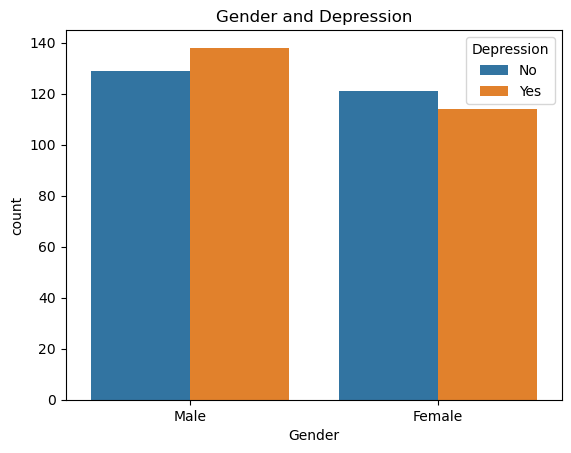

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x="Gender", hue="Depression")
plt.title("Gender and Depression")
plt.show()

The plot illustrates the distribution of depression across genders.
Male students report being depressed slightly more than women.

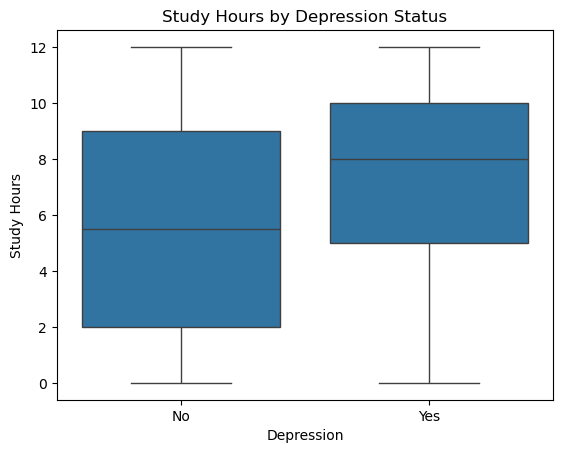

In [13]:
sns.boxplot(data=df, x="Depression", y="Study Hours")
plt.title("Study Hours by Depression Status")
plt.show()

The boxplot compares the distribution of study hours between students with and without depression.  
It indicates that students with depression have a higher median number of study hours than those without depression.

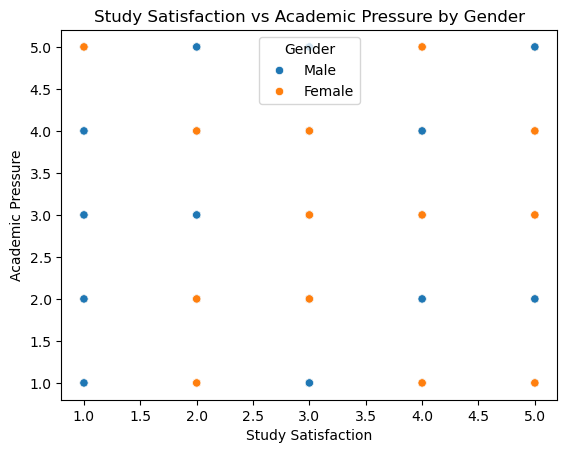

In [14]:
sns.scatterplot(
    data=df,
    x="Study Satisfaction",
    y="Academic Pressure",
    hue="Gender"
)
plt.title("Study Satisfaction vs Academic Pressure by Gender")
plt.show()

The scatter plot illustrates the relationship between study satisfaction and academic pressure by gender.
It doesn't indicate any clear pattern as the points are widely dispersed. 

# TASK 2

In [15]:
netflix = pd.read_csv("netflix_messy.csv")
netflix

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"
...,...,...,...,...,...,...,...,...,...,...
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV


In [16]:
netflix.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [17]:
netflix.shape

(8790, 10)

In [18]:
netflix.duplicated().sum()

np.int64(0)

No duplicate rows were found in the dataset.

In [19]:
netflix.isna().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      8
release_year    0
rating          8
duration        8
listed_in       0
dtype: int64

Missing values were identified in the variables date_added, rating, and duration.

In [20]:
netflix = netflix.dropna()
netflix.shape

(8766, 10)

The rows containing missing values were removed from the dataset. In particular 24 rows (8790-8766=24)

In [21]:
netflix["date_added"] = pd.to_datetime(netflix["date_added"])

/var/folders/g6/f0vvl32s2sdggnt0t4lcrqjm0000gn/T/ipykernel_18129/1974705177.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix["date_added"] = pd.to_datetime(netflix["date_added"])


In [22]:
netflix["type"].unique()

array(['Movie', 'TV Show'], dtype=object)

The dataset contains two content types: Movies and TV Shows.

In [23]:
netflix["type"].value_counts()

type
Movie      6108
TV Show    2658
Name: count, dtype: int64

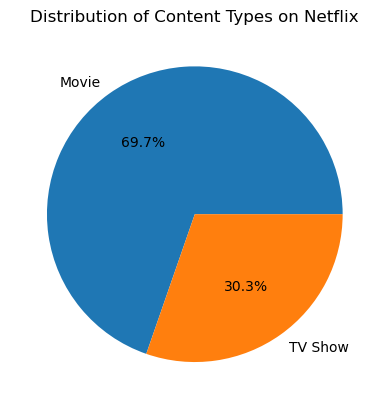

In [24]:
netflix["type"].value_counts().plot.pie(autopct="%1.1f%%")
plt.title("Distribution of Content Types on Netflix")
plt.ylabel("")
plt.show()

The pie chart shows the proportion of movies and TV shows in the dataset, with movies making up 69.7% and tv shows 30.3% of the dataset.

In [25]:
netflix["country"].value_counts().head(5)

country
United States     3225
India             1057
United Kingdom     636
Pakistan           419
Not Given          287
Name: count, dtype: int64

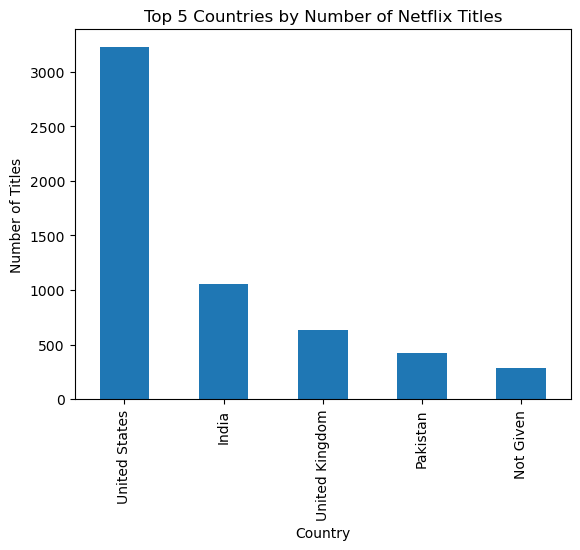

In [26]:
netflix["country"].value_counts().head(5).plot.bar()
plt.title("Top 5 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.show()

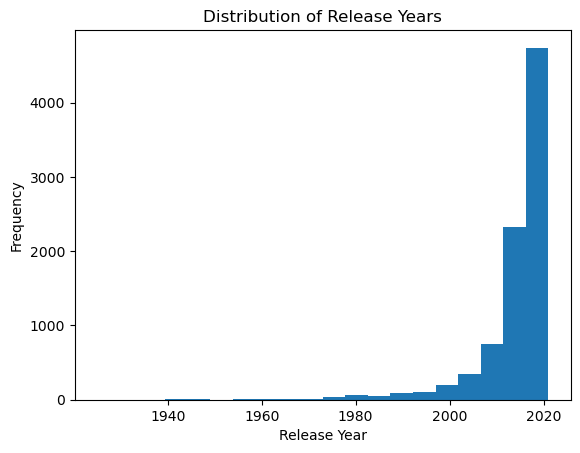

In [27]:
plt.hist(netflix["release_year"], bins=20)
plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Frequency")
plt.show()

The histogram indicates an increase in movies and tv shows released around the 2010s

/var/folders/g6/f0vvl32s2sdggnt0t4lcrqjm0000gn/T/ipykernel_18129/1344762109.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix["decade"] = (netflix["release_year"] // 10) * 10


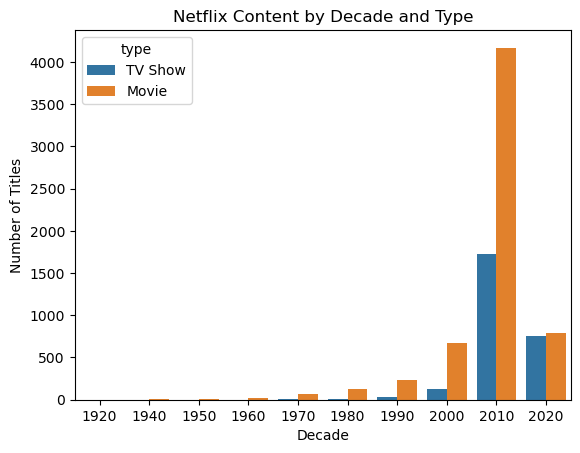

In [29]:
netflix["decade"] = (netflix["release_year"] // 10) * 10

sns.countplot(data=netflix, x="decade", hue="type")
plt.title("Netflix Content by Decade and Type")
plt.xlabel("Decade")
plt.ylabel("Number of Titles")
plt.show()


The plot demonstrates a spike in the number of released titles in the 2010s, with movies clearly dominating that decade as well as earlier ones.